In [1]:
import numpy as np
import pandas as pd

In [2]:
english_sentences = [
    "hello",
    "how are you",
    "i am fine",
    "good morning",
    "thank you",
    "i love you",
    "what is your name",
    "my name is john"
]

hindi_sentences = [
    "नमस्ते",
    "आप कैसे हैं",
    "मैं ठीक हूँ",
    "सुप्रभात",
    "धन्यवाद",
    "मैं तुमसे प्यार करता हूँ",
    "आपका नाम क्या है",
    "मेरा नाम जॉन है"
]

In [3]:
hindi_sentences = ["<start> " + s + " <end>" for s in hindi_sentences]

In [4]:
hindi_sentences

['<start> नमस्ते <end>',
 '<start> आप कैसे हैं <end>',
 '<start> मैं ठीक हूँ <end>',
 '<start> सुप्रभात <end>',
 '<start> धन्यवाद <end>',
 '<start> मैं तुमसे प्यार करता हूँ <end>',
 '<start> आपका नाम क्या है <end>',
 '<start> मेरा नाम जॉन है <end>']

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [6]:
eng_tokenizer = Tokenizer(filters="")
eng_tokenizer.fit_on_texts(english_sentences)
eng_sequences = eng_tokenizer.texts_to_sequences(english_sentences)
hin_tokenizer = Tokenizer(filters="")
hin_tokenizer.fit_on_texts(hindi_sentences)
hindi_sequences = hin_tokenizer.texts_to_sequences(hindi_sentences)

In [7]:
print(eng_tokenizer.word_index,"\n" , hin_tokenizer.word_index)

{'you': 1, 'i': 2, 'is': 3, 'name': 4, 'hello': 5, 'how': 6, 'are': 7, 'am': 8, 'fine': 9, 'good': 10, 'morning': 11, 'thank': 12, 'love': 13, 'what': 14, 'your': 15, 'my': 16, 'john': 17} 
 {'<start>': 1, '<end>': 2, 'मैं': 3, 'हूँ': 4, 'नाम': 5, 'है': 6, 'नमस्ते': 7, 'आप': 8, 'कैसे': 9, 'हैं': 10, 'ठीक': 11, 'सुप्रभात': 12, 'धन्यवाद': 13, 'तुमसे': 14, 'प्यार': 15, 'करता': 16, 'आपका': 17, 'क्या': 18, 'मेरा': 19, 'जॉन': 20}


In [8]:
eng_vocab_size = len(eng_tokenizer.word_index) + 1
hin_vocab_size = len(hin_tokenizer.word_index) + 1

In [9]:
max_eng_len = max([len(s) for s in eng_sequences])
max_hin_len = max([len(s) for s in hindi_sequences])

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [11]:
encoder_input_data = pad_sequences(eng_sequences, maxlen = max_eng_len, padding = "post")
decoder_input_data = pad_sequences(hindi_sequences, maxlen = max_hin_len, padding = "post")

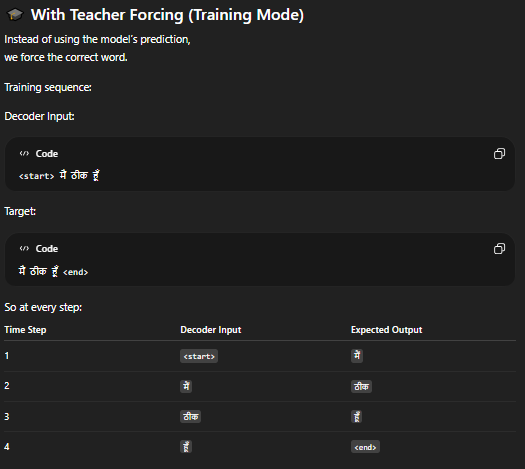

In [12]:
#TEACHER FORCING TARGET
decoder_target = np.zeros_like(decoder_input_data)
decoder_target[:,:-1] = decoder_input_data[:,1:]

In [13]:
decoder_target = np.expand_dims(decoder_target, -1)

In [14]:
embedding_dim = 128

In [15]:
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.models import Model

In [16]:
#ENcoder
encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(eng_vocab_size, embedding_dim)(encoder_inputs)

_, h_state , c_state = LSTM(256, return_state=True)(enc_emb)

encoder_states = [h_state, c_state]

In [17]:
#DEcoder
decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(hin_vocab_size, embedding_dim)(decoder_inputs)

decoder_outputs , _ , _ = LSTM(256, return_state=True, return_sequences=True)(dec_emb, initial_state=encoder_states)
decoder_outputs = Dense(hin_vocab_size, activation='softmax')(decoder_outputs)

In [18]:
#MOdel
model = Model([encoder_inputs,decoder_inputs], decoder_outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 128) │      2,304 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 128) │      2,688 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    394,240 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    394,240 │ embedding_1[0][0… │
│                     │ 256), (None,      │            │ lstm[0][1],       │
│                     │ 256), (None,      │            │ lstm[0][2]        │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 21)  │      5,397 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 798,869 (3.05 MB)

 Trainable params: 798,869 (3.05 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.fit(
    [encoder_input_data,decoder_input_data],
    decoder_target,
    batch_size=2,
    epochs=65,
    validation_split=0.2
    )

Epoch 1/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 343ms/step - accuracy: 0.2946 - loss: 3.0322 - val_accuracy: 0.2857 - val_loss: 3.0238
Epoch 2/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4405 - loss: 2.9249 - val_accuracy: 0.2857 - val_loss: 2.9797
Epoch 3/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5119 - loss: 2.6819 - val_accuracy: 0.2857 - val_loss: 2.8596
Epoch 4/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5655 - loss: 2.0335 - val_accuracy: 0.2857 - val_loss: 2.5099
Epoch 5/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5298 - loss: 1.5720 - val_accuracy: 0.2857 - val_loss: 2.3095
Epoch 6/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5655 - loss: 1.4873 - val_accuracy: 0.2857 - val_loss: 2.2882
Epoch 7/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4405 - loss: 1.8239 - val_accuracy: 0.2857 - val_loss: 2.3003
Epoch 8/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5655 - loss: 1.2243 - val_accuracy: 0.2857 - val_loss: 